# Precificação de Crédito Orientada por Dados — Case de Ciência de Dados

> **Nota:** este notebook foi desenvolvido a partir de um case técnico de precificação de
> crédito recebido em um processo seletivo. Nomes de instituições, caminhos de arquivo e
> quaisquer identificadores foram removidos/anonimizados. Os dados utilizados são **fictícios**,
> fornecidos especificamente para o exercício.

Este estudo constrói uma política de precificação de crédito orientada por dados, a partir de
três bases: **Operações de Crédito**, **Inadimplência** e **Conversão** de propostas em operações.

O notebook está organizado em três grandes blocos:

1. **Preparação dos dados** (seções 1 a 9) — leitura, validação, padronização, engenharia de
   atributos e integração das bases;
2. **Análise exploratória** (seção 10) — identificação das variáveis com maior poder de
   discriminação da inadimplência;
3. **Construção e avaliação da política de precificação** (seções 11 a 13) — definição da
   matriz de taxas, estimativa de conversão, avaliação econômica e síntese final.

📌 **Nota de execução:** os arquivos de dados (`Operacoes_Credito_1.xlsx`, `Inadimplencia_1.xlsx`,
`Conversão_1.xlsx`) não estão incluídos neste repositório por serem dados fornecidos em um
processo seletivo. Para reproduzir os resultados, coloque cópias locais desses arquivos em uma
pasta `dados/` na raiz do projeto.


## 1. Configuração do Ambiente

Nesta etapa são importadas as bibliotecas necessárias para manipulação dos dados, análise
estatística e visualização gráfica. Também são definidas as configurações de exibição do
pandas, a paleta de cores utilizada em todos os gráficos do case e os caminhos das bases de
dados (relativos, para reprodutibilidade em qualquer máquina).

In [1]:
# ============================================================
# 1. CONFIGURAÇÃO DO AMBIENTE
# ============================================================

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from cycler import cycler

# Exibição de tabelas
from IPython.display import display

# ------------------------------------------------------------
# Configurações de exibição
# ------------------------------------------------------------

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.width', 160)

# ------------------------------------------------------------
# Identidade visual dos gráficos
# ------------------------------------------------------------

CORES_SEQ = ["#00703C", "#00995D", "#8DC63F", "#1B4F72", "#5DADE2", "#F9A825"]

CORES_RISCO = {
    "A": "#00995D",   # menor risco
    "B": "#F9A825",   # risco intermediário
    "C": "#C0392B",   # maior risco
}

plt.style.use('default')
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#444444",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "font.size": 11,
    "axes.prop_cycle": cycler(color=CORES_SEQ),
})

# ------------------------------------------------------------
# Caminhos das bases (relativos — ajuste se necessário)
# ------------------------------------------------------------

CAMINHO_OPERACOES = "dados/Operacoes_Credito_1.xlsx"
CAMINHO_INADIMPLENCIA = "dados/Inadimplencia_1.xlsx"
CAMINHO_CONVERSAO = "dados/Conversão_1.xlsx"

print("Ambiente configurado com sucesso!")


Ambiente configurado com sucesso!


## 2. Leitura das Bases de Dados

Nesta etapa são carregadas as três bases disponibilizadas para o desenvolvimento do case:

- **Operações de Crédito**: informações cadastrais das operações concedidas;
- **Inadimplência**: histórico de inadimplência por segmento de clientes;
- **Conversão**: histórico da taxa de conversão de propostas em operações de crédito para
  diferentes níveis de taxa de juros.

As bases de inadimplência e conversão são carregadas inicialmente em formato bruto
(`header=None`), pois possuem cabeçalhos e estrutura matricial que serão tratados nas próximas
etapas.

In [2]:
# ============================================================
# 2. LEITURA DAS BASES
# ============================================================

# Base de operações
op_raw = pd.read_excel(
    CAMINHO_OPERACOES,
    sheet_name="Operacoes_Credito"
)

# Base de inadimplência (estrutura original)
inad_raw = pd.read_excel(
    CAMINHO_INADIMPLENCIA,
    sheet_name="Export",
    header=None
)

# Base de conversão (estrutura original)
conv_raw = pd.read_excel(
    CAMINHO_CONVERSAO,
    sheet_name="Conversao",
    header=None
)

print(f"Operações: {op_raw.shape}")
print(f"Inadimplência (bruta): {inad_raw.shape}")
print(f"Conversão (bruta): {conv_raw.shape}")


Operações: (29384, 11)
Inadimplência (bruta): (4, 22)
Conversão (bruta): (7, 4)


✅ **Resultado:** as três bases foram carregadas com sucesso. As bases de inadimplência e
conversão necessitam de tratamento adicional antes de serem integradas à base principal, uma
vez que apresentam cabeçalho e estrutura matricial distintos da base de operações.

## 3. Análise Inicial da Base de Operações

Antes do tratamento dos dados, foi realizada uma análise exploratória da base de operações para
verificar sua estrutura, tipos de dados e principais variáveis disponíveis. Essa etapa permite
identificar possíveis inconsistências, valores ausentes e compreender as características da
carteira utilizada no estudo.

In [3]:
# ============================================================
# 3. ANÁLISE INICIAL DA BASE DE OPERAÇÕES
# ============================================================

op_raw.info()
display(op_raw.head())
display(op_raw.describe())
display(op_raw.isnull().sum())
print(f'Registros duplicados: {op_raw.duplicated().sum()}')


<class 'pandas.DataFrame'>
RangeIndex: 29384 entries, 0 to 29383
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Ano_Mes                      29384 non-null  int64  
 1   Id_Operacao                  29384 non-null  int64  
 2   Perfil                       29384 non-null  str    
 3   Nicho                        29384 non-null  str    
 4   Classificacao_Risco_Cliente  29384 non-null  str    
 5   Pre_Fixado_Pos_Fixado        29384 non-null  str    
 6   UF_Cliente                   29384 non-null  str    
 7   Vlr_Financiado               29384 non-null  float64
 8   Prazo_Dias_Operacao          29384 non-null  int64  
 9   Idade_Cliente                29384 non-null  int64  
 10  Tempo_Relacionamento_Anos    29384 non-null  int64  
dtypes: float64(1), int64(5), str(5)
memory usage: 2.5 MB
Registros duplicados: 0


,Ano_Mes,Id_Operacao,Perfil,Nicho,Classificacao_Risco_Cliente,Pre_Fixado_Pos_Fixado,UF_Cliente,Vlr_Financiado,Prazo_Dias_Operacao,Idade_Cliente,Tempo_Relacionamento_Anos
0,202602,1,Urbano,Gold,B,PRE,GO,"10,277.00",367,64,3
1,202601,2,Urbano,Platinum,A,PRE,RS,"10,284.79",730,42,13
2,202601,3,Urbano,Platinum,A,PRE,RS,"12,428.54",459,23,13
3,202601,4,Urbano,Platinum,B,PRE,BA,"20,653.00",1471,39,12
4,202601,5,Urbano,Gold,B,PRE,RS,"7,500.00",1466,52,12


,Ano_Mes,Id_Operacao,Vlr_Financiado,Prazo_Dias_Operacao,Idade_Cliente,Tempo_Relacionamento_Anos
count,"29,384.00","29,384.00","29,384.00","29,384.00","29,384.00","29,384.00"
mean,"202,601.59","15,032.11","27,693.23",721.62,43.93,7.51
std,0.49,"8,672.54","110,638.16",506.69,15.27,4.60
min,"202,601.00",1.00,20.26,0.00,18.00,0.00
25%,"202,601.00","7,525.75","3,149.00",326.00,31.00,4.00
50%,"202,602.00","15,033.50","7,500.00",721.00,44.00,8.00
75%,"202,602.00","22,539.25","20,000.00","1,096.00",57.00,11.00
max,"202,602.00","30,037.00","4,681,631.00","3,633.00",70.00,15.00


Ano_Mes                        0
Id_Operacao                    0
Perfil                         0
Nicho                          0
Classificacao_Risco_Cliente    0
Pre_Fixado_Pos_Fixado          0
UF_Cliente                     0
Vlr_Financiado                 0
Prazo_Dias_Operacao            0
Idade_Cliente                  0
Tempo_Relacionamento_Anos      0
dtype: int64

**Principais observações**

- A base contém informações cadastrais das operações de crédito e dos clientes.
- Foram identificadas variáveis relacionadas ao perfil do cliente, características da operação
  e classificação de risco.
- Não foram observadas inconsistências estruturais que impedissem a continuidade da análise.

### 3.1 Validação da variável `Perfil`

Foi realizada uma análise da distribuição da variável `Perfil` para identificar possíveis
inconsistências cadastrais. Foi identificado um único registro pertencente a uma categoria não
prevista pela regra de negócio. Antes de tratá-lo, testamos a hipótese de recuperar o valor
correto a partir do `Nicho` (caso houvesse uma relação unívoca entre as duas variáveis).

In [4]:
# ============================================================
# Validação da variável Perfil
# ============================================================

print("Distribuição da variável Perfil:")
display(op_raw["Perfil"].value_counts())

# Cruzamento com Nicho para validar a consistência da informação
print("\nPerfil x Nicho:")
display(pd.crosstab(op_raw["Perfil"], op_raw["Nicho"]))


Distribuição da variável Perfil:

Perfil x Nicho:


Perfil
Urbano            21967
Rural              7416
Jonas Sulzbach        1
Name: count, dtype: int64

Nicho,Black,Básico,Gold,Platinum
Perfil,,,,
Jonas Sulzbach,0,1,0,0
Rural,0,5541,1246,629
Urbano,2964,6059,7073,5871


O cruzamento mostra que `Nicho == "Black"` só ocorre em `Perfil == "Urbano"`, mas
`Nicho == "Básico"` (assim como Gold/Platinum) aparece tanto em Rural quanto em Urbano — inclusive
com mais casos em Urbano. Ou seja, **não é possível inferir o Perfil correto apenas pelo Nicho**
de forma confiável.

Como se trata de um único registro em quase 30 mil (~0,003% da base), optou-se por removê-lo em
vez de arriscar uma imputação sem base estatística sólida, preservando apenas os perfis
`Urbano` e `Rural`.

In [5]:
# Remoção de registros com perfis não previstos
qtd_inicial = len(op_raw)

op = (
    op_raw[
        op_raw["Perfil"].isin(["Urbano", "Rural"])
    ]
    .copy()
)

qtd_removida = qtd_inicial - len(op)

print(f"Registros removidos: {qtd_removida}")
print(f"Total de registros após o tratamento: {len(op)}")


Registros removidos: 1
Total de registros após o tratamento: 29383


In [6]:
# ============================================================
# Verificações de Qualidade dos Dados
# ============================================================

duplicados = op['Id_Operacao'].duplicated().sum()
nulos = op.isna().sum()
prazo_zero = op[op["Prazo_Dias_Operacao"] == 0]

print(f"Operações duplicadas: {duplicados}")

print("\nValores ausentes por variável:")
display(nulos[nulos > 0])

print(f"\nOperações com prazo igual a zero: {len(prazo_zero)}")

if len(prazo_zero) > 0:
    display(prazo_zero)
else:
    print("Nenhuma inconsistência encontrada.")


Operações duplicadas: 0

Valores ausentes por variável:

Operações com prazo igual a zero: 3


Series([], dtype: int64)

,Ano_Mes,Id_Operacao,Perfil,Nicho,Classificacao_Risco_Cliente,Pre_Fixado_Pos_Fixado,UF_Cliente,Vlr_Financiado,Prazo_Dias_Operacao,Idade_Cliente,Tempo_Relacionamento_Anos
8236,202601,8433,Urbano,Platinum,B,PRE,RS,"4,234.00",0,43,10
24317,202602,24877,Urbano,Black,A,PRE,RS,"10,151.00",0,58,3
28978,202602,29631,Urbano,Black,B,PRE,PR,"4,000.00",0,37,6


⚠️ **Resultado da validação:** foram identificadas 3 operações com prazo igual a zero,
indicando possíveis inconsistências cadastrais. Esses registros foram sinalizados e tratados na
padronização a seguir, sem serem excluídos da base — dado o volume irrelevante, a decisão de
como tratá-los na modelagem de custo de risco é revisitada na seção 11.

## 4. Padronização da Base de Operações

Após a validação da qualidade dos dados, foram realizados ajustes na estrutura da base para
facilitar as análises posteriores:

- criação de um indicador para operações com prazo atípico;
- conversão da variável de competência para o formato de data;
- padronização do nome da variável de classificação de risco;
- conversão das variáveis categóricas para o tipo `category`, visando melhor organização e
  otimização de memória.

In [7]:
# ============================================================
# 4. PADRONIZAÇÃO DA BASE DE OPERAÇÕES
# ============================================================

op["Flag_Prazo_Atipico"] = op["Prazo_Dias_Operacao"] == 0

op["Ano_Mes"] = pd.to_datetime(
    op["Ano_Mes"].astype(str),
    format="%Y%m"
)

op = op.rename(
    columns={
        "Classificacao_Risco_Cliente": "Classificacao_Risco"
    }
)

colunas_categoricas = [
    "Perfil",
    "Nicho",
    "Classificacao_Risco",
    "Pre_Fixado_Pos_Fixado",
    "UF_Cliente"
]

op[colunas_categoricas] = op[colunas_categoricas].astype("category")

display(op.dtypes)


Ano_Mes                      datetime64[us]
Id_Operacao                           int64
Perfil                             category
Nicho                              category
Classificacao_Risco                category
Pre_Fixado_Pos_Fixado              category
UF_Cliente                         category
Vlr_Financiado                      float64
Prazo_Dias_Operacao                   int64
Idade_Cliente                         int64
Tempo_Relacionamento_Anos             int64
Flag_Prazo_Atipico                     bool
dtype: object

✅ **Resultado:** a base de operações foi padronizada para as etapas seguintes do estudo.

## 5. Engenharia de Atributos

Com o objetivo de facilitar a análise exploratória e a definição da política de precificação,
foram criadas variáveis categóricas a partir das características originais das operações. As
faixas foram definidas considerando critérios de negócio, permitindo comparar grupos de clientes
com características semelhantes e identificar padrões de inadimplência entre diferentes
segmentos da carteira.

In [8]:
# ============================================================
# 5. ENGENHARIA DE ATRIBUTOS
# ============================================================

# Faixa de Prazo da Operação (dias -> faixas aproximadas em meses)
op["Faixa_Prazo"] = pd.cut(
    op["Prazo_Dias_Operacao"],
    bins=[-1, 365, 730, 1095, 1460, np.inf],
    labels=["Até 12m", "13-24m", "25-36m", "37-48m", "Acima de 48m"]
)

# Faixa de Idade do Cliente
op["Faixa_Idade"] = pd.cut(
    op["Idade_Cliente"],
    bins=[0, 25, 35, 45, 55, 65, np.inf],
    labels=["Até 25", "26-35", "36-45", "46-55", "56-65", "Acima de 65"]
)

# Faixa de Tempo de Relacionamento
op["Faixa_Relacionamento"] = pd.cut(
    op["Tempo_Relacionamento_Anos"],
    bins=[-1, 1, 3, 6, 10, np.inf],
    labels=["Até 1 ano", "2-3 anos", "4-6 anos", "7-10 anos", "Acima de 10 anos"]
)

# Faixa de Valor Financiado
op["Faixa_Valor"] = pd.cut(
    op["Vlr_Financiado"],
    bins=[0, 5_000, 20_000, 50_000, 200_000, np.inf],
    labels=["Até 5k", "5k-20k", "20k-50k", "50k-200k", "Acima de 200k"]
)

display(
    op[["Faixa_Prazo", "Faixa_Idade", "Faixa_Relacionamento", "Faixa_Valor"]].describe()
)


,Faixa_Prazo,Faixa_Idade,Faixa_Relacionamento,Faixa_Valor
count,29383,29383,29383,29383
unique,5,6,5,5
top,Até 12m,36-45,Acima de 10 anos,5k-20k
freq,10177,5631,9226,11696


As novas variáveis categóricas serão utilizadas nas análises exploratórias para identificar
segmentos da carteira com diferentes níveis de inadimplência.

## 6. Preparação da Base de Inadimplência

A base de inadimplência foi disponibilizada em formato matricial, com informações distribuídas
em diferentes linhas do cabeçalho. Para possibilitar sua integração com a base de operações, foi
necessário reconstruir a tabela em formato tabular, utilizando como dimensões: **Perfil**,
**Nicho** e **Classificação de Risco**.

In [9]:
# ============================================================
# 6. PREPARAÇÃO DA BASE DE INADIMPLÊNCIA
# ============================================================

linha_perfil = inad_raw.iloc[0].ffill()
linha_nicho = inad_raw.iloc[1].ffill()
linha_risco = inad_raw.iloc[2]
linha_inad = inad_raw.iloc[3]

inad = pd.DataFrame({
    "Perfil": linha_perfil.iloc[1:].values,
    "Nicho": linha_nicho.iloc[1:].values,
    "Classificacao_Risco": linha_risco.iloc[1:].values,
    "Inadimplencia": pd.to_numeric(linha_inad.iloc[1:].values)
})

display(inad)


,Perfil,Nicho,Classificacao_Risco,Inadimplencia
0,Rural,Básico,A,0.18
1,Rural,Básico,B,0.22
2,Rural,Básico,C,0.26
3,Rural,Gold,A,0.12
4,Rural,Gold,B,0.18
5,Rural,Gold,C,0.20
6,Rural,Platinum,A,0.03
7,Rural,Platinum,B,0.07
8,Rural,Platinum,C,0.09
9,Urbano,Básico,A,0.28


In [10]:
print(inad.info())
display(inad.head())
display(inad.describe())


<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Perfil               21 non-null     str    
 1   Nicho                21 non-null     str    
 2   Classificacao_Risco  21 non-null     str    
 3   Inadimplencia        21 non-null     float64
dtypes: float64(1), str(3)
memory usage: 804.0 bytes
None


,Perfil,Nicho,Classificacao_Risco,Inadimplencia
0,Rural,Básico,A,0.18
1,Rural,Básico,B,0.22
2,Rural,Básico,C,0.26
3,Rural,Gold,A,0.12
4,Rural,Gold,B,0.18


,Inadimplencia
count,21.00
mean,0.19
std,0.11
min,0.03
25%,0.10
50%,0.18
75%,0.26
max,0.44


✅ **Resultado do tratamento:** a base de inadimplência passou a possuir uma estrutura
tabular, permitindo sua integração com a base de operações. Vale destacar (ponto retomado na
seção 11): este percentual é definido, no enunciado do case, como a inadimplência observada
**até 12 meses** após a concessão — não é ainda a inadimplência "madura"/estabilizada da
operação.

## 7. Preparação da Base de Conversão

A base de conversão foi disponibilizada em formato matricial, apresentando as taxas de conversão
para diferentes combinações de taxa de juros e classificação de risco. Para facilitar a
integração com a política de precificação proposta, a base foi convertida para o formato *long*,
no qual cada linha representa uma combinação única de Taxa de Juros Mensal, Classificação de
Risco e Taxa de Conversão.

In [11]:
# ============================================================
# 7. PREPARAÇÃO DA BASE DE CONVERSÃO
# ============================================================

cabecalho_risco = conv_raw.iloc[0, 1:].values

conv = conv_raw.iloc[2:].copy()
conv.columns = ["Taxa_Juros_Mensal", *cabecalho_risco]

conv["Taxa_Juros_Mensal"] = pd.to_numeric(conv["Taxa_Juros_Mensal"])

conv_long = conv.melt(
    id_vars="Taxa_Juros_Mensal",
    var_name="Classificacao_Risco",
    value_name="Taxa_Conversao"
)

conv_long["Taxa_Conversao"] = pd.to_numeric(conv_long["Taxa_Conversao"])

conv_long = (
    conv_long
    .sort_values(["Classificacao_Risco", "Taxa_Juros_Mensal"])
    .reset_index(drop=True)
)

display(conv_long)


,Taxa_Juros_Mensal,Classificacao_Risco,Taxa_Conversao
0,0.02,A,0.39
1,0.03,A,0.26
2,0.04,A,0.19
3,0.05,A,0.14
4,0.06,A,0.10
5,0.02,B,0.55
6,0.03,B,0.43
7,0.04,B,0.39
8,0.05,B,0.35
9,0.06,B,0.24


✅ **Resultado do tratamento:** a base de conversão passou a representar cada combinação de
Classificação de Risco e Taxa de Juros Mensal em uma única linha, permitindo estimar a conversão
esperada da política proposta a partir do histórico disponibilizado.

## 8. Validação das Chaves de Integração

Antes da integração das bases de operações e inadimplência, foi realizada uma validação das
chaves de relacionamento, garantindo que todas as combinações de `Perfil`, `Nicho` e
`Classificação de Risco` existentes na base de operações possuíam correspondente na base de
inadimplência.

In [12]:
# ============================================================
# 8. VALIDAÇÃO DAS CHAVES DE INTEGRAÇÃO
# ============================================================

chaves_operacoes = set(
    op[["Perfil", "Nicho", "Classificacao_Risco"]]
    .drop_duplicates()
    .apply(tuple, axis=1)
)

chaves_inad = set(
    inad[["Perfil", "Nicho", "Classificacao_Risco"]]
    .apply(tuple, axis=1)
)

faltantes = chaves_operacoes - chaves_inad

print(f"Combinações sem correspondência: {len(faltantes)}")

if faltantes:
    print("\nCombinações não encontradas:")
    for chave in sorted(faltantes):
        print(chave)
else:
    print("Todas as combinações possuem correspondência na base de inadimplência.")


Combinações sem correspondência: 0
Todas as combinações possuem correspondência na base de inadimplência.


✅ **Resultado da validação:** todas as combinações possuem correspondência — a remoção do
registro inválido de `Perfil` na seção 3.1 foi suficiente para destravar o cruzamento.

## 9. Integração das Bases

A base de operações foi integrada à base de inadimplência, utilizando `Perfil`, `Nicho` e
`Classificação de Risco`. Foi utilizado um relacionamento do tipo *many-to-one*, garantindo que
cada operação recebesse o percentual histórico de inadimplência correspondente ao seu
segmento.

In [13]:
# ============================================================
# 9. INTEGRAÇÃO DAS BASES
# ============================================================

op_tratado = op.merge(
    inad,
    on=["Perfil", "Nicho", "Classificacao_Risco"],
    how="left",
    validate="many_to_one"
)

nulos_inad = op_tratado["Inadimplencia"].isna().sum()
print(f"Operações sem percentual de inadimplência: {nulos_inad}")

display(op_tratado.head())


Operações sem percentual de inadimplência: 0


,Ano_Mes,Id_Operacao,Perfil,Nicho,Classificacao_Risco,Pre_Fixado_Pos_Fixado,UF_Cliente,Vlr_Financiado,Prazo_Dias_Operacao,Idade_Cliente,Tempo_Relacionamento_Anos,Flag_Prazo_Atipico,Faixa_Prazo,Faixa_Idade,Faixa_Relacionamento,Faixa_Valor,Inadimplencia
0,2026-02-01,1,Urbano,Gold,B,PRE,GO,"10,277.00",367,64,3,False,13-24m,56-65,2-3 anos,5k-20k,0.27
1,2026-01-01,2,Urbano,Platinum,A,PRE,RS,"10,284.79",730,42,13,False,13-24m,36-45,Acima de 10 anos,5k-20k,0.10
2,2026-01-01,3,Urbano,Platinum,A,PRE,RS,"12,428.54",459,23,13,False,13-24m,Até 25,Acima de 10 anos,5k-20k,0.10
3,2026-01-01,4,Urbano,Platinum,B,PRE,BA,"20,653.00",1471,39,12,False,Acima de 48m,36-45,Acima de 10 anos,20k-50k,0.14
4,2026-01-01,5,Urbano,Gold,B,PRE,RS,"7,500.00",1466,52,12,False,Acima de 48m,46-55,Acima de 10 anos,5k-20k,0.27


✅ **Resultado da integração:** a integração foi concluída sem valores ausentes. A partir
desta etapa, a base consolidada (`op_tratado`) concentra todas as informações necessárias para
as análises exploratórias e para a construção da política de precificação.

## 10. Análise Exploratória da Carteira

Após a integração das bases, foi realizada uma análise exploratória com o objetivo de
identificar quais características da carteira apresentavam maior capacidade de discriminar a
inadimplência.

### 10.1 Inadimplência Média por Segmento

In [14]:
# ============================================================
# 10.1 INADIMPLÊNCIA MÉDIA POR SEGMENTO
# ============================================================

variaveis = [
    "Perfil", "Nicho", "Classificacao_Risco",
    "Faixa_Valor", "Faixa_Prazo", "Faixa_Relacionamento", "Faixa_Idade"
]

for var in variaveis:
    print(f"\n{'='*70}")
    print(f"Inadimplência média por {var}")
    print(f"{'='*70}")

    resumo = (
        op_tratado
        .groupby(var, observed=True)
        .agg(
            Quantidade_Operacoes=("Id_Operacao", "count"),
            Inadimplencia_Media=("Inadimplencia", "mean"),
            Valor_Carteira=("Vlr_Financiado", "sum")
        )
        .sort_values("Inadimplencia_Media", ascending=False)
        .round(4)
    )
    display(resumo)



Inadimplência média por Perfil

Inadimplência média por Nicho

Inadimplência média por Classificacao_Risco

Inadimplência média por Faixa_Valor

Inadimplência média por Faixa_Prazo

Inadimplência média por Faixa_Relacionamento

Inadimplência média por Faixa_Idade


,Quantidade_Operacoes,Inadimplencia_Media,Valor_Carteira
Perfil,,,
Urbano,21967,0.22,"257,685,442.73"
Rural,7416,0.16,"556,035,234.70"


,Quantidade_Operacoes,Inadimplencia_Media,Valor_Carteira
Nicho,,,
Básico,11600,0.28,"193,375,025.70"
Gold,8319,0.23,"203,760,683.78"
Platinum,6500,0.11,"319,235,298.47"
Black,2964,0.07,"97,349,669.48"


,Quantidade_Operacoes,Inadimplencia_Media,Valor_Carteira
Classificacao_Risco,,,
C,2733,0.40,"23,278,980.11"
B,10503,0.23,"168,110,012.84"
A,16147,0.16,"622,331,684.48"


,Quantidade_Operacoes,Inadimplencia_Media,Valor_Carteira
Faixa_Valor,,,
Até 5k,10401,0.25,"26,122,404.30"
5k-20k,11696,0.20,"117,133,214.19"
20k-50k,4419,0.15,"139,157,340.07"
50k-200k,2270,0.13,"210,780,892.04"
Acima de 200k,597,0.08,"320,526,826.83"


,Quantidade_Operacoes,Inadimplencia_Media,Valor_Carteira
Faixa_Prazo,,,
13-24m,6404,0.22,"109,700,752.45"
25-36m,5433,0.20,"128,520,663.64"
37-48m,4620,0.20,"198,450,412.00"
Acima de 48m,2749,0.20,"121,695,082.24"
Até 12m,10177,0.20,"255,353,767.10"


,Quantidade_Operacoes,Inadimplencia_Media,Valor_Carteira
Faixa_Relacionamento,,,
4-6 anos,5430,0.21,"141,574,299.91"
Acima de 10 anos,9226,0.21,"261,517,493.85"
Até 1 ano,3679,0.21,"105,640,926.44"
2-3 anos,3630,0.20,"102,173,329.90"
7-10 anos,7418,0.20,"202,814,627.33"


,Quantidade_Operacoes,Inadimplencia_Media,Valor_Carteira
Faixa_Idade,,,
36-45,5631,0.21,"154,427,395.70"
26-35,5480,0.21,"145,018,723.21"
Até 25,4500,0.21,"123,562,642.73"
56-65,5588,0.21,"151,482,783.15"
46-55,5480,0.20,"162,456,878.75"
Acima de 65,2704,0.20,"76,772,253.89"


🔍 **Interpretação inicial:** as tabelas acima permitem comparar o comportamento da
inadimplência entre os diferentes segmentos da carteira. Nesta etapa ainda não são definidas
regras de precificação; o objetivo é identificar quais variáveis apresentam maior capacidade de
diferenciar o risco de crédito.

### 10.2 Análise Gráfica da Inadimplência

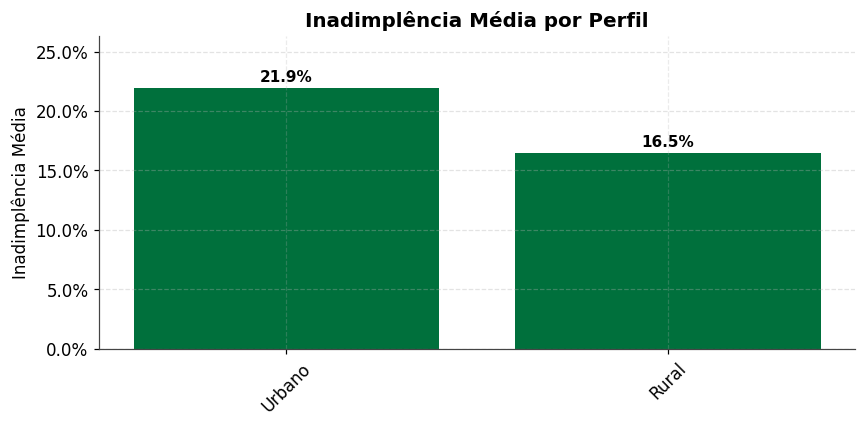

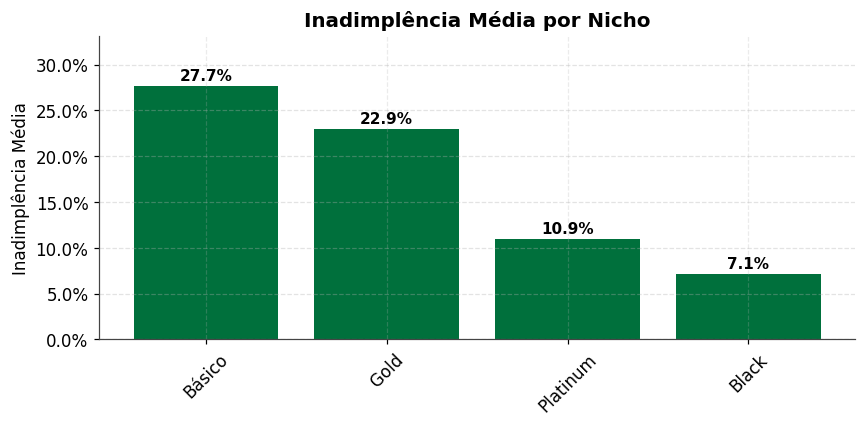

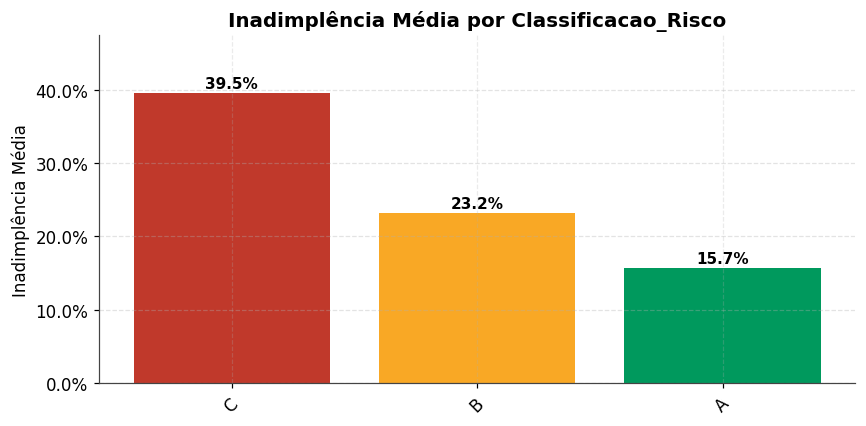

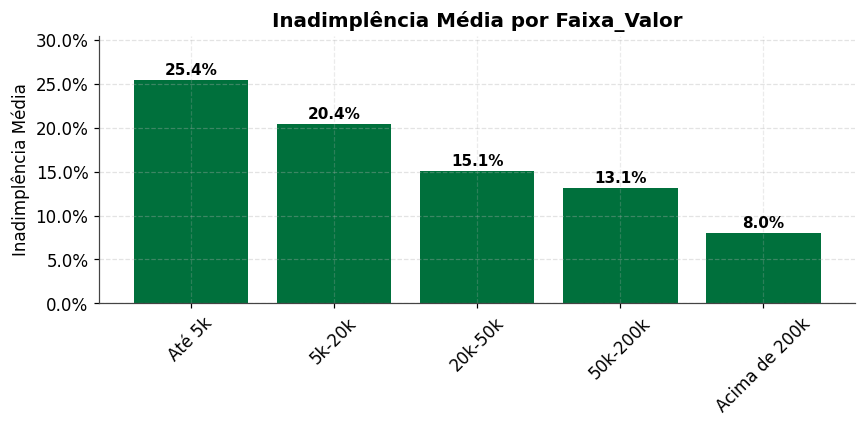

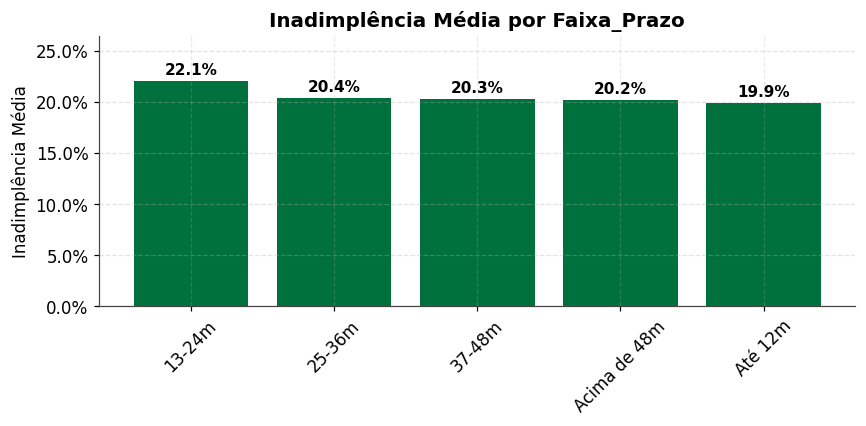

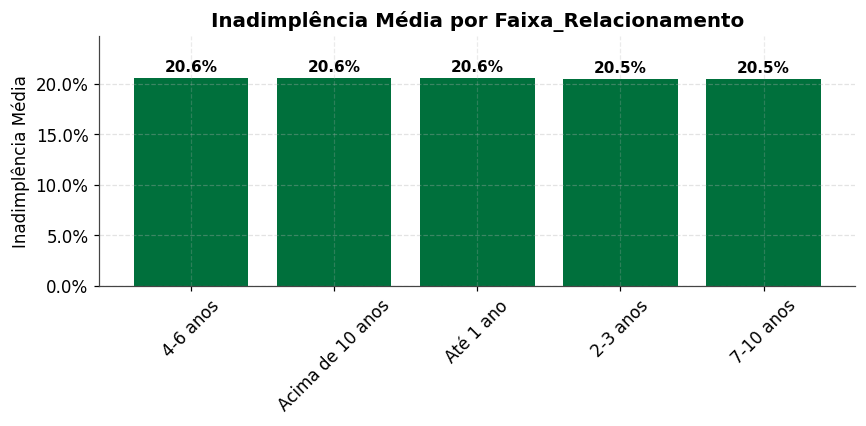

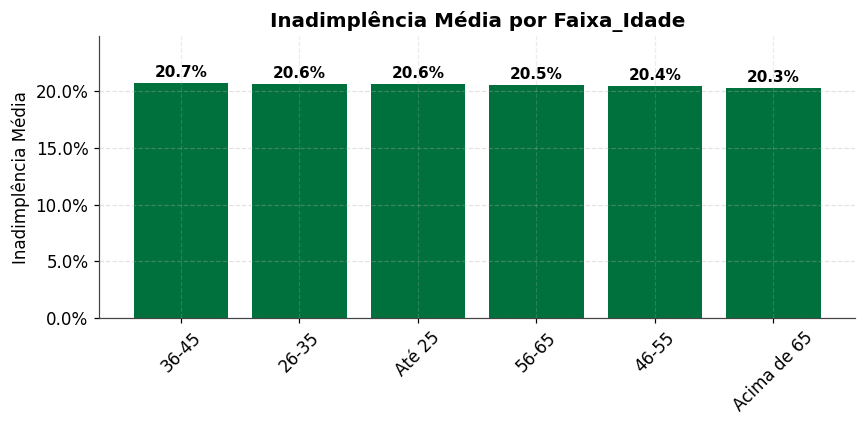

In [15]:
# ============================================================
# 10.2 ANÁLISE GRÁFICA DA INADIMPLÊNCIA
# ============================================================

for var in variaveis:
    resumo = (
        op_tratado
        .groupby(var, observed=True)["Inadimplencia"]
        .mean()
        .sort_values(ascending=False)
    )

    if var == "Classificacao_Risco":
        cores = [CORES_RISCO.get(cat, "#00995D") for cat in resumo.index.astype(str)]
    else:
        cores = CORES_SEQ[0]

    fig, ax = plt.subplots(figsize=(8, 4))
    barras = ax.bar(resumo.index.astype(str), resumo.values, color=cores)

    ax.set_title(f'Inadimplência Média por {var}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Inadimplência Média')
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    plt.xticks(rotation=45)

    for barra in barras:
        altura = barra.get_height()
        ax.text(
            barra.get_x() + barra.get_width()/2, altura + 0.003,
            f'{altura:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

    ax.set_ylim(0, resumo.max()*1.20)
    plt.tight_layout()
    plt.show()


### 10.3 Principais Achados da Análise Exploratória

A análise exploratória demonstrou que a inadimplência não se distribui de forma homogênea entre
os diferentes segmentos da carteira. Os principais resultados observados foram:

- A **Classificação de Risco** apresentou o maior poder de discriminação da inadimplência,
  confirmando sua relevância como principal direcionador da política de precificação.
- A **Faixa de Valor Financiado** também apresentou diferenças relevantes de inadimplência,
  mantendo comportamento distinto mesmo dentro de uma mesma classificação de risco.
- As variáveis Perfil, Nicho, Prazo, Idade e Tempo de Relacionamento apresentaram menor
  capacidade de diferenciação e, por esse motivo, não foram utilizadas como direcionadores
  isolados da política proposta.

### 10.4 Poder de Discriminação das Variáveis

Foi calculada a amplitude da inadimplência (diferença entre a maior e a menor média) para cada
variável analisada, como proxy de poder de discriminação.

In [16]:
# ============================================================
# 10.4 PODER DE DISCRIMINAÇÃO DAS VARIÁVEIS
# ============================================================

resultado = []
for var in variaveis:
    resumo = op_tratado.groupby(var, observed=True)["Inadimplencia"].mean()
    resultado.append({
        "Variável": var,
        "Maior Inadimplência": resumo.max(),
        "Menor Inadimplência": resumo.min(),
        "Diferença": resumo.max() - resumo.min()
    })

resultado = pd.DataFrame(resultado).sort_values("Diferença", ascending=False)

display(
    resultado.style
    .format({"Maior Inadimplência": "{:.2%}", "Menor Inadimplência": "{:.2%}", "Diferença": "{:.2%}"})
    .background_gradient(subset=["Diferença"], cmap="Greens")
)


,Variável,Maior Inadimplência,Menor Inadimplência,Diferença
2,Classificacao_Risco,39.51%,15.66%,23.85%
1,Nicho,27.66%,7.14%,20.51%
3,Faixa_Valor,25.39%,7.98%,17.41%
0,Perfil,21.94%,16.46%,5.48%
4,Faixa_Prazo,22.07%,19.90%,2.17%
6,Faixa_Idade,20.73%,20.27%,0.46%
5,Faixa_Relacionamento,20.62%,20.45%,0.17%


Complementarmente, avalia-se o cruzamento entre Classificação de Risco e Nicho — a segunda
variável com maior poder de discriminação isolado — para verificar se ela adiciona informação
relevante além da já capturada pela Classificação de Risco.

In [17]:
(
    op_tratado
    .groupby(["Classificacao_Risco", "Nicho"], observed=True)
    .agg(Operacoes=("Id_Operacao", "count"), Inadimplencia=("Inadimplencia", "mean"))
    .round(4)
)


### Conclusão e Seleção das Variáveis da Política de Precificação

A análise exploratória demonstrou que Classificação de Risco, Nicho e Faixa de Valor
apresentaram maior capacidade de discriminar a inadimplência da carteira.

Buscando uma política de precificação simples, transparente e operacionalmente viável,
optou-se por utilizar apenas a **Classificação de Risco** e a **Faixa de Valor** como
direcionadores da política proposta.

A Classificação de Risco foi definida como principal variável por representar a avaliação
consolidada do risco de crédito da operação. A Faixa de Valor foi incorporada por demonstrar
capacidade adicional de discriminar a inadimplência mesmo dentro de uma mesma classificação de
risco, permitindo um refinamento da precificação.

Embora o Nicho também tenha apresentado diferenças relevantes de inadimplência, sua incorporação
aumentaria significativamente a complexidade da política, elevando o número de combinações de
taxas e dificultando sua implementação e manutenção. Optou-se por mantê-lo como variável de
**monitoramento**, candidata a uma futura revisão da política.

### 10.5 Avaliação da Faixa de Valor dentro da Classificação de Risco

In [18]:
# ============================================================
# 10.5 AVALIAÇÃO CONJUNTA: RISCO x FAIXA DE VALOR
# ============================================================

resumo_risco_valor = (
    op_tratado
    .groupby(["Classificacao_Risco", "Faixa_Valor"], observed=True)
    .agg(Operacoes=("Id_Operacao", "count"), Inadimplencia=("Inadimplencia", "mean"))
    .round(4)
)

display(resumo_risco_valor)


Operacoes  Inadimplencia
Classificacao_Risco Faixa_Valor                            
A                   Até 5k              4002           0.19

💡 **Interpretação:** a Faixa de Valor continua diferenciando a inadimplência mesmo dentro de
uma mesma classificação de risco. Em todos os níveis de risco, as operações de menor valor
apresentaram maiores percentuais de inadimplência — resultado que justifica sua utilização como
variável complementar na política de precificação proposta.

### 10.6 Representatividade da Faixa de Valor na Carteira

In [19]:
# ============================================================
# 10.6 REPRESENTATIVIDADE DA FAIXA DE VALOR
# ============================================================

resumo = (
    op_tratado
    .groupby(["Classificacao_Risco", "Faixa_Valor"], observed=True)
    .agg(
        Operacoes=("Id_Operacao", "count"),
        Valor_Carteira=("Vlr_Financiado", "sum"),
        Inadimplencia=("Inadimplencia", "mean")
    )
    .reset_index()
)

resumo["% Operacoes"] = resumo["Operacoes"] / resumo["Operacoes"].sum()
resumo["% Valor Carteira"] = resumo["Valor_Carteira"] / resumo["Valor_Carteira"].sum()
resumo = resumo.sort_values(["Classificacao_Risco", "Faixa_Valor"])

display(
    resumo.style.format({
        "Valor_Carteira": "R$ {:,.0f}", "Inadimplencia": "{:.2%}",
        "% Operacoes": "{:.2%}", "% Valor Carteira": "{:.2%}"
    })
)


,Classificacao_Risco,Faixa_Valor,Operacoes,Valor_Carteira,Inadimplencia,% Operacoes,% Valor Carteira
0,A,Até 5k,4002,"R$ 10,636,403",18.97%,13.62%,1.31%
1,A,5k-20k,6602,"R$ 68,995,672",16.39%,22.47%,8.48%
2,A,20k-50k,3191,"R$ 101,706,444",13.40%,10.86%,12.50%
3,A,50k-200k,1848,"R$ 172,928,812",12.05%,6.29%,21.25%
4,A,Acima de 200k,504,"R$ 268,064,354",7.26%,1.72%,32.94%
5,B,Até 5k,4718,"R$ 11,701,572",25.06%,16.06%,1.44%
6,B,5k-20k,4264,"R$ 40,342,052",23.27%,14.51%,4.96%
7,B,20k-50k,1071,"R$ 32,623,847",17.75%,3.64%,4.01%
8,B,50k-200k,363,"R$ 32,805,085",15.83%,1.24%,4.03%
9,B,Acima de 200k,87,"R$ 50,637,457",11.43%,0.30%,6.22%


In [20]:
(
    op_tratado
    .groupby('Faixa_Valor', observed=True)
    .agg(Operacoes=('Id_Operacao', 'count'), Inadimplencia=('Inadimplencia', 'mean'))
    .assign(Representatividade=lambda x: x['Operacoes'] / x['Operacoes'].sum())
    .sort_values('Inadimplencia', ascending=False)
    .style.format({'Inadimplencia': '{:.2%}', 'Representatividade': '{:.2%}'})
)


🎯 **Principais achados:** a análise confirmou que a Faixa de Valor não apenas diferencia a
inadimplência dentro de cada classificação de risco, como também apresenta elevada
representatividade na carteira. As operações de até R$ 20 mil concentram a maior parte das
operações e, ao mesmo tempo, os maiores percentuais de inadimplência em todas as classificações
de risco — reforçando sua utilização como variável complementar na política.

## 11. Construção da Política de Precificação

Com base nos direcionadores identificados na análise exploratória — Classificação de Risco e
Faixa de Valor — foi construída a política de precificação. Esta etapa contempla a definição das
premissas financeiras, o agrupamento das faixas de valor, a construção da matriz de taxas e a
estimativa dos impactos em conversão e resultado esperado.

### 11.1 Premissas Financeiras

A política de precificação contempla três componentes:

$$\text{Taxa Final} = \text{Custo de Risco} + \text{Custo de Funding} + \text{Spread}$$

**Custo de funding.** Considerado equivalente a 100% do CDI, assumindo uma taxa anual de 15%,
convertida para taxa efetiva mensal.

**Custo de risco — da inadimplência observada (12m) ao custo de risco por operação.** O
percentual de `Inadimplencia` disponibilizado na base é, por definição do exercício, medido
**até 12 meses** após a concessão do crédito. O enunciado também estabelece que a inadimplência
**cresce linearmente da concessão até 24 meses**, estabilizando-se a partir desse ponto. Duas
implicações práticas decorrem disso:

1. **O valor aos 12 meses não é o valor final.** Se a rampa é linear entre 0 (na concessão) e o
   patamar estabilizado em 24 meses, o valor observado aos 12 meses corresponde à metade do
   caminho. Logo, a inadimplência estabilizada é aproximadamente:
   $$\text{Inad}_{24m} \approx 2 \times \text{Inad}_{12m}$$
2. **O custo de risco de cada operação depende do seu próprio prazo**, não apenas do segmento.
   Uma operação de 6 meses ainda está "subindo a rampa" da inadimplência (carrega menos risco
   acumulado do que uma operação de 3 anos, que já ultrapassou o ponto de estabilização).

Formalizando o custo de risco **mensal** de cada operação, com base no prazo em meses
($n$) e na inadimplência estabilizada ($\text{Inad}_{24m}$):

$$
\text{Custo de Risco Mensal} =
\frac{\text{Inad}_{24m}}{\max(n,\ 24)}
$$

- Para operações com prazo **até 24 meses**, a perda esperada até o vencimento cresce
  proporcionalmente ao prazo (ainda na rampa), o que faz o custo mensal amortizado ser
  constante e igual a $\text{Inad}_{24m}/24$, independentemente do prazo específico dentro
  desse intervalo.
- Para operações com prazo **acima de 24 meses**, a perda esperada já está estabilizada em
  $\text{Inad}_{24m}$; ao amortizá-la por um prazo maior, o custo mensal diminui
  proporcionalmente — refletindo que uma perda fixa, diluída em mais parcelas, pesa menos por
  mês.

As 3 operações com `Prazo_Dias_Operacao == 0` (sinalizadas na seção 3.1) são tratadas com um
piso de 24 meses no denominador (via `.clip(lower=24)`), evitando divisão por zero e assumindo,
de forma conservadora, que operações "instantâneas" recebem o mesmo custo mensal de uma
operação típica de até 24 meses.

In [21]:
# ============================================================
# 11.1 PREMISSAS FINANCEIRAS
# ============================================================

# --- Custo de funding: 100% CDI (premissa de 15% a.a.), convertido para taxa mensal efetiva ---
funding = (1 + 0.15) ** (1/12) - 1

# --- Custo de risco: extrapolação da inadimplência (12m -> 24m) e amortização pelo prazo ---
op_tratado["Inadimplencia_Estabilizada_24m"] = op_tratado["Inadimplencia"] * 2

op_tratado["Prazo_Meses"] = op_tratado["Prazo_Dias_Operacao"] / 30

op_tratado["Custo_Risco_Mensal"] = (
    op_tratado["Inadimplencia_Estabilizada_24m"]
    / op_tratado["Prazo_Meses"].clip(lower=24)
)

print(f"Funding mensal considerado: {funding:.2%}")
print(f"Custo de risco mensal médio da carteira: {op_tratado['Custo_Risco_Mensal'].mean():.2%}")
display(
    op_tratado[["Prazo_Meses", "Inadimplencia", "Inadimplencia_Estabilizada_24m", "Custo_Risco_Mensal"]]
    .describe()
)


Funding mensal considerado: 1.17%
Custo de risco mensal médio da carteira: 1.45%


,Prazo_Meses,Inadimplencia,Inadimplencia_Estabilizada_24m,Custo_Risco_Mensal
count,"29,383.00","29,383.00","29,383.00","29,383.00"
mean,24.05,0.21,0.41,0.01
std,16.89,0.10,0.21,0.01
min,0.00,0.03,0.07,0.00
25%,10.87,0.12,0.23,0.01
50%,24.03,0.18,0.36,0.01
75%,36.53,0.27,0.55,0.02
max,121.10,0.44,0.88,0.04


### 11.2 Agrupamento das Faixas de Valor

Para manter a política simples e operacionalmente viável, as cinco faixas de valor identificadas
na análise exploratória foram consolidadas em três grupos.

In [22]:
# ============================================================
# 11.2 AGRUPAMENTO DAS FAIXAS DE VALOR
# ============================================================

def grupo_valor(x):
    if x in ["Até 5k", "5k-20k"]:
        return "Até 20k"
    elif x == "20k-50k":
        return "20k-50k"
    else:
        return "Acima 50k"

op_tratado["Grupo_Valor"] = op_tratado["Faixa_Valor"].apply(grupo_valor)

display(op_tratado["Grupo_Valor"].value_counts().rename("Operações").to_frame())


,Operações
Grupo_Valor,
Até 20k,22097
20k-50k,4419
Acima 50k,2867


### 11.3 Definição da Matriz de Precificação

Com base na análise exploratória, foi construída uma matriz de taxas considerando Classificação
de Risco e Grupo de Valor, buscando equilibrar risco esperado, competitividade, conversão
estimada e simplicidade operacional.

In [23]:
# ============================================================
# 11.3 MATRIZ DE PRECIFICAÇÃO
# ============================================================

politica = {
    ("A", "Até 20k"): 0.03, ("A", "20k-50k"): 0.02, ("A", "Acima 50k"): 0.02,
    ("B", "Até 20k"): 0.04, ("B", "20k-50k"): 0.03, ("B", "Acima 50k"): 0.03,
    ("C", "Até 20k"): 0.06, ("C", "20k-50k"): 0.05, ("C", "Acima 50k"): 0.05
}

display(
    pd.Series(politica).rename("Taxa Proposta").to_frame().style.format("{:.0%}")
)


### 11.4 Aplicação da Política

Cada operação recebeu a taxa correspondente ao seu segmento de risco e grupo de valor.

In [24]:
# ============================================================
# 11.4 APLICAÇÃO DA POLÍTICA
# ============================================================

op_tratado["Taxa_Nova"] = (
    op_tratado[["Classificacao_Risco", "Grupo_Valor"]]
    .apply(tuple, axis=1)
    .map(politica)
)


### 11.5 Estimativa da Conversão Esperada

Cada operação foi associada à taxa histórica de conversão correspondente à sua classificação de
risco e à taxa de juros atribuída.

In [25]:
# ============================================================
# 11.5 ESTIMATIVA DA CONVERSÃO
# ============================================================

op_tratado = op_tratado.merge(
    conv_long,
    left_on=["Classificacao_Risco", "Taxa_Nova"],
    right_on=["Classificacao_Risco", "Taxa_Juros_Mensal"],
    how="left"
)


### 11.6 Avaliação Econômica da Política

Como indicador simplificado de desempenho, foi estimado o resultado esperado da política
considerando a taxa de juros proposta, o custo de funding, o custo de risco mensal (já ajustado
na seção 11.1) e a conversão estimada.

In [26]:
# ============================================================
# 11.6 RESULTADO ESPERADO
# ============================================================

assert "Taxa_Conversao" in op_tratado.columns, (
    "Coluna 'Taxa_Conversao' não encontrada em op_tratado. "
    "Execute novamente a seção 11.5 (merge com conv_long) antes desta célula."
)

op_tratado["Resultado_Esperado"] = (
    (
        op_tratado["Taxa_Nova"]
        - funding
        - op_tratado["Custo_Risco_Mensal"]
    )
    * op_tratado["Taxa_Conversao"]
)

display(op_tratado[["Taxa_Nova", "Custo_Risco_Mensal", "Taxa_Conversao", "Resultado_Esperado"]].describe())


,Taxa_Nova,Custo_Risco_Mensal,Taxa_Conversao,Resultado_Esperado
count,"29,383.00","29,383.00","29,383.00","29,383.00"
mean,0.03,0.01,0.35,0.00
std,0.01,0.01,0.07,0.00
min,0.02,0.00,0.26,-0.01
25%,0.03,0.01,0.26,0.00
50%,0.03,0.01,0.39,0.00
75%,0.04,0.02,0.39,0.01
max,0.06,0.04,0.47,0.02


## 12. Resultados da Política Proposta

Com a política de precificação aplicada a toda a carteira, esta seção reúne a leitura executiva
dos resultados sob quatro ângulos complementares: volume, conversão, resultado econômico e
consolidação.

### 12.1 Distribuição da Carteira pela Nova Taxa

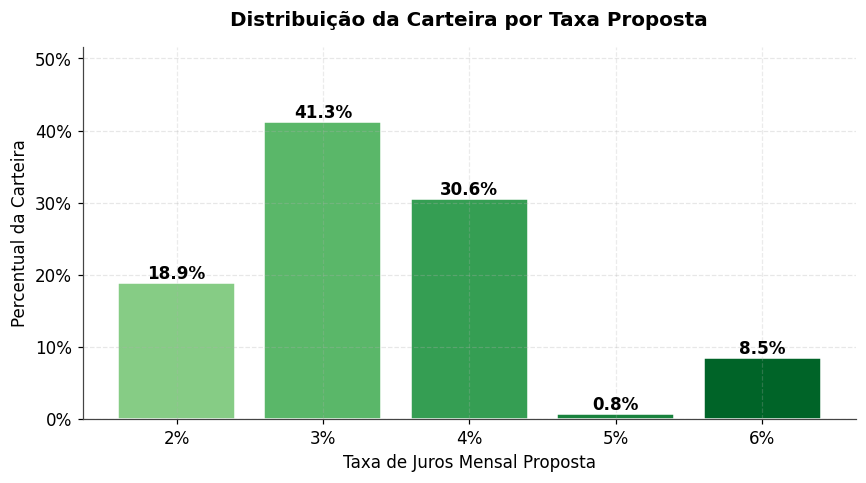

In [27]:
# ============================================================
# 12.1 DISTRIBUIÇÃO DA CARTEIRA PELA NOVA TAXA
# ============================================================

distribuicao = (
    op_tratado.groupby('Taxa_Nova').size().reset_index(name='Operacoes')
)
distribuicao['Percentual'] = distribuicao['Operacoes'] / distribuicao['Operacoes'].sum()

cores_dist = plt.cm.Greens(np.linspace(0.45, 0.90, len(distribuicao)))

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.bar(
    distribuicao['Taxa_Nova'].map(lambda x: f"{x:.0%}"),
    distribuicao['Percentual'], color=cores_dist, edgecolor="white"
)

ax.set_title('Distribuição da Carteira por Taxa Proposta', pad=14)
ax.set_xlabel('Taxa de Juros Mensal Proposta')
ax.set_ylabel('Percentual da Carteira')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(0, distribuicao['Percentual'].max() * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.3)

for barra in barras:
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2, altura, f'{altura:.1%}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


💡 **Leitura do gráfico:** as taxas de 3% e 4% concentram, juntas, a maior parte da carteira
(em torno de 70% das operações), coerente com a predominância de clientes com classificação de
risco A e B identificada na seção 10. As taxas extremas representam parcelas bem menores da
carteira.

### 12.2 Conversão Esperada por Classificação de Risco

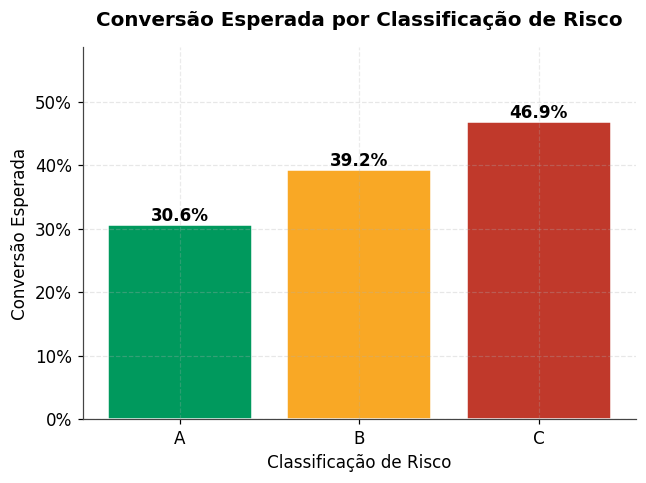

In [28]:
# ============================================================
# 12.2 CONVERSÃO ESPERADA POR CLASSIFICAÇÃO DE RISCO
# ============================================================

conversao = (
    op_tratado.groupby("Classificacao_Risco", observed=True)
    .agg(Conversao=("Taxa_Conversao", "mean"))
    .reset_index()
)

cores_conv = [CORES_RISCO.get(c, "#00995D") for c in conversao["Classificacao_Risco"]]

fig, ax = plt.subplots(figsize=(6, 4.5))
barras = ax.bar(conversao["Classificacao_Risco"], conversao["Conversao"], color=cores_conv, edgecolor="white")

ax.set_title("Conversão Esperada por Classificação de Risco", pad=14)
ax.set_xlabel("Classificação de Risco")
ax.set_ylabel("Conversão Esperada")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(0, conversao["Conversao"].max() * 1.25)
ax.grid(axis="y", alpha=.3)

for barra in barras:
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2, altura, f"{altura:.1%}",
            ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()


💡 **Leitura do gráfico:** a conversão esperada cresce à medida que o risco aumenta — menor
no risco A e mais alta no risco C. Uma hipótese razoável é que clientes de maior risco tenham
menos alternativas de crédito disponíveis no mercado, aceitando condições menos favoráveis com
maior frequência; já clientes de menor risco, com mais opções, tendem a ser mais seletivos mesmo
diante de taxas mais baixas. Essa leitura é uma hipótese a validar com a área comercial, e não
uma conclusão causal.

### 12.3 Resultado Esperado por Segmento (Risco x Grupo de Valor)

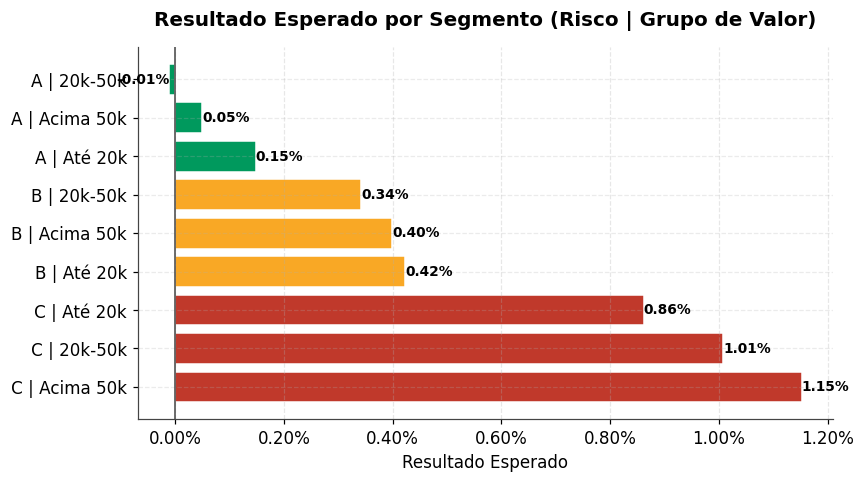

In [29]:
# ============================================================
# 12.3 RESULTADO ESPERADO POR SEGMENTO
# ============================================================

resultado_seg = (
    op_tratado.groupby(["Classificacao_Risco", "Grupo_Valor"], observed=True)
    .agg(Resultado=("Resultado_Esperado", "mean"))
    .reset_index()
)

resultado_seg["Segmento"] = resultado_seg["Classificacao_Risco"] + " | " + resultado_seg["Grupo_Valor"]
resultado_seg = resultado_seg.sort_values("Resultado", ascending=False)

cores_result = [CORES_RISCO.get(c, "#00995D") for c in resultado_seg["Classificacao_Risco"]]

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.barh(resultado_seg["Segmento"], resultado_seg["Resultado"], color=cores_result, edgecolor="white")

ax.axvline(0, color="#444444", linewidth=1)
ax.set_title("Resultado Esperado por Segmento (Risco | Grupo de Valor)", pad=14)
ax.set_xlabel("Resultado Esperado")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.grid(axis="x", alpha=.3)

for barra in barras:
    largura = barra.get_width()
    ax.text(largura, barra.get_y() + barra.get_height()/2, f"{largura:.2%}",
            va="center", ha="right" if largura < 0 else "left", fontweight="bold", fontsize=9)

plt.tight_layout()
plt.show()


💡 **Leitura do gráfico:** com o custo de risco corretamente amortizado (seção 11.1), a
política apresenta resultado esperado **positivo na maior parte dos segmentos**, crescente com o
nível de risco (o spread embutido na matriz de taxas mais do que compensa o maior custo de
crédito nos segmentos B e C). O único segmento próximo de zero é **A | 20k-50k**, muito perto do
breakeven — um candidato natural para revisão fina da taxa (seção 13).

### 12.4 Matriz Consolidada de Precificação

In [30]:
# ============================================================
# 12.4 MATRIZ CONSOLIDADA DE PRECIFICAÇÃO
# ============================================================

politica_df = (
    op_tratado
    .groupby(["Classificacao_Risco", "Grupo_Valor"], observed=True)["Taxa_Nova"]
    .mean()
    .unstack()
    .loc[:, ["Até 20k", "20k-50k", "Acima 50k"]]
)

display(
    politica_df.style
    .format("{:.0%}")
    .background_gradient(cmap="Greens", axis=None)
    .set_caption("Taxa de juros mensal proposta por segmento")
)


Grupo_Valor,Até 20k,20k-50k,Acima 50k
Classificacao_Risco,,,
A,3%,2%,2%
B,4%,3%,3%
C,6%,5%,5%


✅ A matriz confirma a lógica esperada: as taxas crescem com o risco (A → B → C) e decrescem
com o valor financiado dentro de cada classificação — recompensando operações maiores,
historicamente menos inadimplentes.

### 12.5 Painel Consolidado por Faixa de Taxa

In [31]:
# ============================================================
# 12.5 PAINEL CONSOLIDADO POR FAIXA DE TAXA
# ============================================================

painel = (
    op_tratado.groupby("Taxa_Nova", observed=True)
    .agg(
        Operacoes=("Id_Operacao", "count"),
        Conversao=("Taxa_Conversao", "mean"),
        Resultado=("Resultado_Esperado", "mean")
    )
    .reset_index()
)

painel["% Carteira"] = painel["Operacoes"] / painel["Operacoes"].sum()

display(
    painel.set_index("Taxa_Nova").style.format({
        "Operacoes": "{:,.0f}", "Conversao": "{:.1%}", "Resultado": "{:.2%}", "% Carteira": "{:.1%}"
    })
)


,Operacoes,Conversao,Resultado,% Carteira
Taxa_Nova,,,,
0.020000,"5,543",38.8%,0.01%,18.9%
0.030000,"12,125",28.4%,0.17%,41.3%
0.040000,"8,982",38.6%,0.42%,30.6%
0.050000,222,47.0%,1.05%,0.8%
0.060000,"2,511",46.8%,0.86%,8.5%


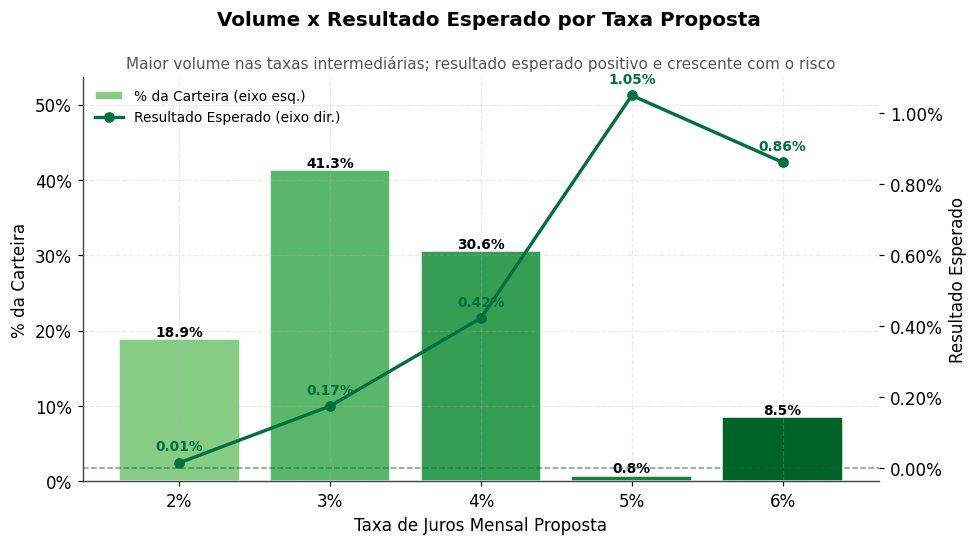

In [32]:
# ------------------------------------------------------------
# Gráfico combinado: volume (barras) x resultado esperado (linha)
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(9, 5))

x_labels = painel["Taxa_Nova"].map(lambda x: f"{x:.0%}")
cores_painel = plt.cm.Greens(np.linspace(0.45, 0.90, len(painel)))

barras = ax1.bar(x_labels, painel["% Carteira"], color=cores_painel, edgecolor="white",
                  label="% da Carteira (eixo esq.)")

ax1.set_xlabel("Taxa de Juros Mensal Proposta")
ax1.set_ylabel("% da Carteira")
ax1.yaxis.set_major_formatter(PercentFormatter(1))
ax1.set_ylim(0, painel["% Carteira"].max() * 1.3)

for barra in barras:
    altura = barra.get_height()
    ax1.text(barra.get_x() + barra.get_width()/2, altura, f"{altura:.1%}",
              ha="center", va="bottom", fontsize=9, fontweight="bold")

ax2 = ax1.twinx()
ax2.plot(x_labels, painel["Resultado"], color="#00703C", marker="o", linewidth=2.2,
         label="Resultado Esperado (eixo dir.)")
ax2.axhline(0, color="#00703C", linestyle="--", linewidth=1, alpha=0.6)
ax2.set_ylabel("Resultado Esperado")
ax2.yaxis.set_major_formatter(PercentFormatter(1))
ax2.grid(False)

for xi, yi in zip(x_labels, painel["Resultado"]):
    ax2.annotate(f"{yi:.2%}", (xi, yi), textcoords="offset points", xytext=(0, 8),
                 ha="center", fontsize=9, fontweight="bold", color="#00703C")

fig.suptitle("Volume x Resultado Esperado por Taxa Proposta", fontsize=13, fontweight="bold")
ax1.set_title("Maior volume nas taxas intermediárias; resultado esperado positivo e crescente com o risco",
              fontsize=10, fontweight="normal", color="#555555")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=False, fontsize=9)

plt.tight_layout()
plt.show()


🎯 **Síntese da seção 12:** a política concentra volume nas faixas de risco/valor mais
representativas da carteira, mantém uma lógica de precificação coerente com o risco, e — com o
custo de risco corretamente amortizado pelo prazo — apresenta resultado esperado positivo na
maior parte dos cortes analisados.

## 13. Conclusão do Case e Recomendações

### 13.1 Síntese do Estudo

**O que foi feito.** A partir de três bases brutas — operações, inadimplência e conversão —, foi
construída uma base analítica única (`op_tratado`), validada e enriquecida com variáveis de
negócio. A análise exploratória (seção 10) identificou a **Classificação de Risco** e a
**Faixa de Valor Financiado** como os principais direcionadores de risco da carteira, superando
variáveis como Perfil, Prazo, Idade e Tempo de Relacionamento.

**O que foi proposto.** Com base nesses dois direcionadores, foi construída uma matriz de
precificação com 9 combinações de taxa (3 níveis de risco x 3 grupos de valor), variando de 2% a
6% ao mês. A política concentra cerca de 70% da carteira nas taxas de 3% e 4%, refletindo o
perfil predominante de risco A/B da base.

**Como o custo de risco foi tratado.** O ponto metodológico mais sensível do exercício é traduzir
a inadimplência observada aos 12 meses em um custo de risco mensal comparável à taxa de juros.
A solução adotada (seção 11.1) extrapola a inadimplência estabilizada em 24 meses a partir do
valor observado (assumindo rampa linear) e amortiza esse valor pelo prazo real de cada operação —
resultando em um indicador de Resultado Esperado consistente e majoritariamente positivo, com
apenas um segmento (A | 20k-50k) próximo do breakeven.

### 13.2 Recomendações para Próximos Passos

- **Revisar o segmento A | 20k-50k**, hoje próximo do breakeven — avaliar se um pequeno ajuste de
  spread nesse segmento específico melhora o resultado sem comprometer a conversão esperada.
- **Monitorar o Nicho** como variável candidata a uma futura revisão da política — apresentou a
  segunda maior amplitude de inadimplência, mas foi mantido fora da matriz nesta versão para
  preservar a simplicidade operacional.
- **Validar a hipótese de conversão crescente com o risco** (seção 12.2) junto à área comercial,
  antes de assumir esse padrão como estável para fins de precificação futura.
- **Testar a política de forma controlada** (piloto ou teste A/B) antes do rollout completo, já
  que a conversão estimada parte de dados históricos e pode não se repetir exatamente sob as
  novas taxas.
- **Revisar periodicamente a matriz de taxas**, à medida que novos dados de inadimplência e
  conversão forem observados sob a política vigente, mantendo o modelo atualizado.
- **Aprimorar o custo de funding**, substituindo a premissa simplificada de CDI fixo (15% a.a.)
  por uma curva de juros projetada (DI futuro) compatível com o prazo de cada operação — relevante
  dado que a carteira é composta por operações pré-fixadas com prazos que variam de dias a mais
  de 10 anos.
